# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 05: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_05_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993. https://doi.org/10.24432/C5859H.</font>

## <font color='green'>Preparação</font>

In [1]:
!pip install pandas scikit-learn ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# Importar o dataset Auto MPG (ID 9)
auto_mpg = fetch_ucirepo(id=9)

# Extrair as variáveis independentes (X) e a variável alvo (y)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# Ver as primeiras linhas
display(X.head())

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [3]:
print(f"Total de valores faltantes x: {X.isna().sum().sum()}")
print(f"Total de valores faltantes y: {y.isna().sum().sum()}")

# Removendo os valores nulos de x
X = X.dropna()

print(f"Total de valores faltantes em x após remoção: {X.isna().sum().sum()}")


Total de valores faltantes x: 6
Total de valores faltantes y: 0
Total de valores faltantes em x após remoção: 0


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

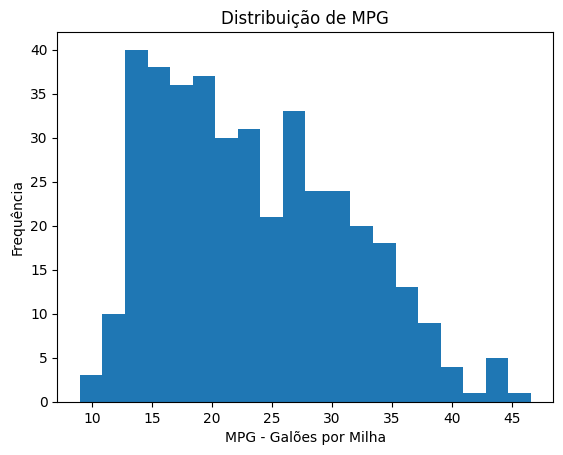

In [4]:
import matplotlib.pyplot as plt

plt.hist(y, bins=20)
plt.title('Distribuição de MPG')
plt.xlabel('MPG - Galões por Milha')
plt.ylabel('Frequência')
plt.show()

### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

Podemos observar uma concentração maior na faixa de consumo entre 10 e 30 galões por milha, onde obtemos um pico em aproximadamente 13 a 15 MPG. Poucos carros superam a taxa de 35 MPG, estes que seriam os carros mais econômicos, porém não são outliers necessariamente.

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

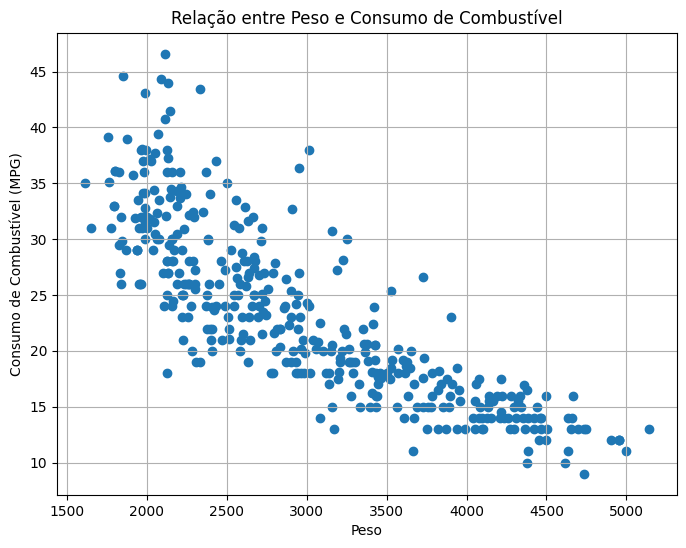

In [5]:
# mantendo em y os indices presentes em X por conta do tratamento na questao 1
y = y.loc[X.index]

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X['weight'], y)
plt.title('Relação entre Peso e Consumo de Combustível')
plt.xlabel('Peso')
plt.ylabel('Consumo de Combustível (MPG)')
plt.grid(True)
plt.show()

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

Podemos notar que conforme o Peso do veícula aumenta o consumo (MPG) diminui, ao observar alguns pontos podemos perceber que a característica principal desse gráfico de dispersão está mais semelhante a uma curva do que uma reta, ou seja, uma regressão linear poderia funcionar, mas idealmente uma regressão polinomial de 2° grau poderia se adaptar melhor aos dados

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

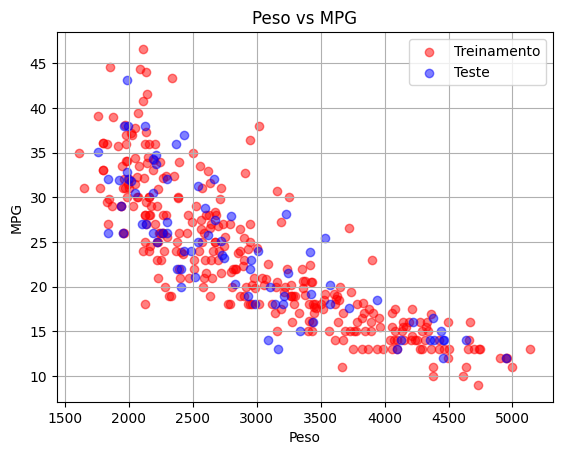

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

plt.scatter(x_train['weight'], y_train, color='red', alpha=0.5, label='Treinamento')
plt.scatter(x_test['weight'], y_test, color='blue', alpha=0.5, label='Teste')
plt.title('Peso vs MPG')
plt.xlabel("Peso")
plt.ylabel("MPG")
plt.grid(True)
plt.legend()
plt.show()

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

Sim, podem,os dizer que são representativos do conjunto original, visto que  a distribuição visual dos pontos no gráfico não aparenta concentração anormal em nenhum ponto específico, ou seja, o conjunto de teste está seguindo bem a base de treinamento.


### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train[['weight']], y_train)

y_pred_train = model.predict(x_train[['weight']])
y_pred_test  = model.predict(x_test[['weight']])

print(f"R² treinamento:  {r2_score(y_train, y_pred_train):.4f}")
print(f"MAE treinamento: {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"MSE treinamento: {mean_squared_error(y_train, y_pred_train):.4f}")

print(f"\nR² teste:  {r2_score(y_test, y_pred_test):.4f}")
print(f"MAE teste: {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"MSE teste: {mean_squared_error(y_test, y_pred_test):.4f}")

R² treinamento:  0.6973
MAE treinamento: 3.2397
MSE treinamento: 18.7346

R² teste:  0.6683
MAE teste: 3.4554
MSE teste: 18.4574


### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

O modelo está apresentando um bom ajuste. No conjunto de treinamento observamos um coeficiente de determinação próximo de 70%, um bom valor que indica como o modelo capta a relação entre as variáveis, o que já indica que o modelo não sofre de underfitting. Embora, ao tratarmos da generalização no conjunto de teste, o modelo tenha caído de aproximadamente 69,73% para 66,83%, o valor não sofreu uma redução significante o suficiente para indicar overfitting.

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

In [8]:
# importando regressão polinomial de grau 2 para novo modelo
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

model2 = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

model2.fit(x_train[['weight']], y_train)

y2_pred_train = model2.predict(x_train[['weight']])
y2_pred_test = model2.predict(x_test[['weight']])

print(f"R² treinamento:  {r2_score(y_train, y2_pred_train):.4f}")
print(f"MAE treinamento: {mean_absolute_error(y_train, y2_pred_train):.4f}")
print(f"MSE treinamento: {mean_squared_error(y_train, y2_pred_train):.4f}")

print(f"\nR² teste:  {r2_score(y_test, y2_pred_test):.4f}")
print(f"MAE teste: {mean_absolute_error(y_test, y2_pred_test):.4f}")
print(f"MSE teste: {mean_squared_error(y_test, y2_pred_test):.4f}")

R² treinamento:  0.7191
MAE treinamento: 3.0172
MSE treinamento: 17.3845

R² teste:  0.6941
MAE teste: 3.2065
MSE teste: 17.0210


### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

O modelo polinomial de grau 2 apresenta sinais de bom ajuste. Comparando com o modelo linear anterior, houve uma melhora em todas as métricas: o R² subiu de 69,73% para 71,91% no treino e de 66,83% para 69,41% no teste, enquanto o MAE caiu de 3,24 para 3,02 no treino e de 3,46 para 3,21 no teste. Isso confirma que a curvatura polinomial captura melhor a relação entre peso e MPG, como já era esperado pelo scatter plot da Q5. A diferença pequena entre treino e teste indica boa generalização, sem sinais de overfitting.

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


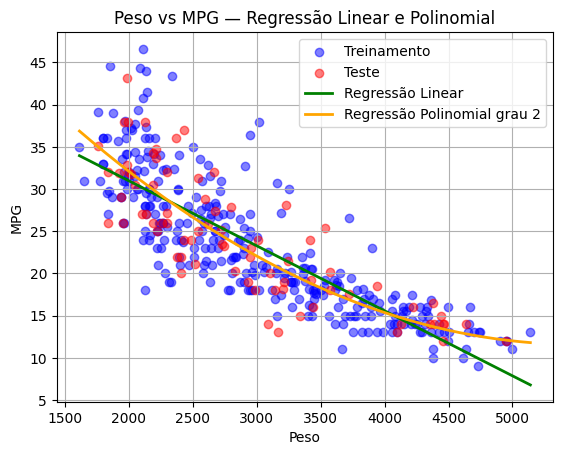

In [9]:
import numpy as np

weight_range = np.linspace(X['weight'].min(), X['weight'].max(), 300).reshape(-1, 1)

y_line = model.predict(weight_range)
y_poly_line = model2.predict(weight_range)

plt.scatter(x_train['weight'], y_train, color='blue', alpha=0.5, label='Treinamento')
plt.scatter(x_test['weight'], y_test, color='red', alpha=0.5, label='Teste')

plt.plot(weight_range, y_line, color='green', linewidth=2, label='Regressão Linear')
plt.plot(weight_range, y_poly_line, color='orange', linewidth=2, label='Regressão Polinomial grau 2')

plt.title('Peso vs MPG — Regressão Linear e Polinomial')
plt.xlabel("Peso")
plt.ylabel("MPG")
plt.legend()
plt.grid(True)
plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

Observando o gráfico percebe-se que o modelo da regressão polinomial de 2° grau se ajusta melhor aos dados, já que estes seguem uma distribuição melhor interpretada por uma parábola. Algo que também foi confirmado pelos dados de R², MAE e MSE do modelo. A relação parece ser linear

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

Sim, podemos observar que os dados são consistentes. Possíveis diferenças vem de que a avaliação quantitativa nos mostra a porcentagem de erros cometidos pelo modelo, o que visualmente podemos observa pelos pontos mais distantes da curva

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [10]:
model_over = Pipeline([
    ('poly', PolynomialFeatures(degree=20, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

model_over.fit(x_train[['weight']], y_train)

y_over_pred_train = model_over.predict(x_train[['weight']])
y_over_pred_test = model_over.predict(x_test[['weight']])

print(f"R² treinamento:  {r2_score(y_train, y_over_pred_train):.4f}")
print(f"MAE treinamento: {mean_absolute_error(y_train, y_over_pred_train):.4f}")
print(f"MSE treinamento: {mean_squared_error(y_train, y_over_pred_train):.4f}")

print(f"\nR² teste:  {r2_score(y_test, y_over_pred_test):.4f}")
print(f"MAE teste: {mean_absolute_error(y_test, y_over_pred_test):.4f}")
print(f"MSE teste: {mean_squared_error(y_test, y_over_pred_test):.4f}")

R² treinamento:  0.7276
MAE treinamento: 2.9801
MSE treinamento: 16.8567

R² teste:  0.6993
MAE teste: 3.2066
MSE teste: 16.7342


Podemos observar que o desempenho aumenta significativamente no conjunto de treino, porém da mesma forma, decai no conjunto de teste, o que indica que o modelo não consegue generalizar bem e está decorando os dados do conjunto de treinamento.

## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [11]:
from sklearn.linear_model import SGDRegressor

model_sgd = SGDRegressor()

model_sgd.fit(X, y)
y_sgd_pred = model_sgd.predict(X)

print(f"R² treinamento:  {r2_score(y, y_sgd_pred):.4f}")
print(f"MAE treinamento: {mean_absolute_error(y, y_sgd_pred):.4f}")
print(f"MSE treinamento: {mean_squared_error(y, y_sgd_pred):.4f}")

R² treinamento:  -185923789633786408274929647616.0000
MAE treinamento: 3251772121418961.0000
MSE treinamento: 11297238599721892365166396309504.0000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [12]:
model_sgd_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(max_iter=1000, random_state=42))
])

model_sgd_scaled.fit(X, y)
y_sgd_scaled_pred = model_sgd_scaled.predict(X)


print(f"R² treinamento:  {r2_score(y, y_sgd_scaled_pred):.4f}")
print(f"MAE treinamento: {mean_absolute_error(y, y_sgd_scaled_pred):.4f}")
print(f"MSE treinamento: {mean_squared_error(y, y_sgd_scaled_pred):.4f}")

R² treinamento:  0.8198
MAE treinamento: 2.4921
MSE treinamento: 10.9483


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

Como o algoritmo baseado em gradiente descendente aprende o modelo dado por dado, isso o torna muito sensível à escala dos dados, considerando que antes de aplicar o standard scaler os dados variavam, por exemplo, de 1500 a 5000 para o peso e de 3 a 8 para os cilindros, essa diferença entre os dados faz o gradiente explodir, divergindo o modelo.

Após a escala podemos observar que as métricas se estabilizam e comportam-se como o esperado para o treinamento.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [13]:
from sklearn.linear_model import Lasso

model_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0))
])

model_lasso.fit(X, y)
model_lasso.predict(X)
coeficientes = model_lasso['lasso'].coef_

for feature, coef_val in zip(X.columns, coeficientes):
    print(f"{feature:15s}: {coef_val:.4f}")

displacement   : -0.0000
cylinders      : -0.0000
horsepower     : -0.1677
weight         : -4.5455
acceleration   : 0.0000
model_year     : 1.9944
origin         : 0.3083


Sim, mudou, já que o modelo treinado pela regressão lasso é muito sensível à escala. Visto que se uma variável possui escala 100x maior, o seu coeficiente calculado na regressão lasso vai se tornar 100x menor, algo que faria com que o modelo eliminasse a variável considerando ela irrelevante pelo coeficiente baixo.

### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

In [14]:
model_lasso1 = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1))
])

model_lasso2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0))
])


model_lasso3 = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=5.0))
])

for model in [model_lasso1, model_lasso2, model_lasso3]:
    model.fit(X, y)
    model.predict(X)
    coeficientes = model['lasso'].coef_

    print(f"Sobreviventes de alpha {model['lasso'].get_params()['alpha']}:  ")
    for feature, coef_val in zip(X.columns, coeficientes):
        if coef_val != 0:
            print(f"{feature:15s}: {coef_val:.4f}")

    print()

Sobreviventes de alpha 0.1:  
horsepower     : -0.3417
weight         : -4.7402
acceleration   : 0.0305
model_year     : 2.6473
origin         : 0.8902

Sobreviventes de alpha 1.0:  
horsepower     : -0.1677
weight         : -4.5455
model_year     : 1.9944
origin         : 0.3083

Sobreviventes de alpha 5.0:  
weight         : -1.4874



Conforme o valor de alpha aumenta podemos observar que a complexidade do modelo diminui, tendo em vista que um maior número de variáveis é descartada como inúteis para o modelo, como podemos ver com o coeficiente alpha=5.0, onde apenas uma variável foi julgada como relevante.